# Age Estimation and Gender Classification

In this assignment, you will train CNN models to estimate a person's age and predict their gender based on face images. Please read carefully all the instructions before you start to write your code.

**Your Tasks**

You are supposed to train two CNN models.
- Model A: Train a CNN model from scratch, following a few restrictions. Save this model as `age_gender_A.keras`
- Model B: Fine-tune a pre-trained model to perform the same task. Save this model as `age_gender_B.keras`

**Dataset**

Your models will be trained and validated on a folder `train_val/` containing 5,000 labeled face images (size: 128 x 128), originated from the UTKFace dataset. During the assessment phase, your code will be tested on unseen test data.

**Performance Metric**

The evaluation of your models on the test set will be based on the following metrics:
- age estimation: - Mean Absolute Error (MAE)
- gender prediction: accuracy

**GPU Time Management**

Please use the available GPU time wisely, as there are some limitations on free GPU usage. It is said the users can use up to 12 hours in row in Google Colab. But many people found they reached its limit far less than 12 hours. To minimize the risk of reaching the limit, consider the following suggestions:
1. Ensure you have a stable internet connection.
2. Carefully validate your hyperparameters before starting the training process.
3. Based on past experience, each model should be trained in less than 2 hours. If the training time is significantly longer, you may need to adjust your model architecture.


## Setting Up: Mount the google drive
Mount your google drive to the notebook. Also don't forget to **enable GPU** before your training.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Visualize a few photos
It's always beneficial to thoroughly understand your data before beginning the training process. To get a first-hand impression of the dataset, please display a minimum of 20 images from the `train_val/` folder, along with their corresponding age and gender labels. This will help you gain initial insights into the dataset.

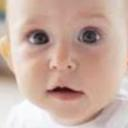

In [2]:
from PIL import Image

img_path = '/content/drive/MyDrive/ComSci/CNN_CourseWork/train_val/1_0_0_20161219140642920.jpg.chip.jpg'
img = Image.open(img_path)

img.show()
display(img)

## Step 1: Data Pre-Processing
In this step, you will perform necessary pre-processing tasks before feeding the data into a CNN. The pre-processing includes:

1. Splitting the data into training and validation sets.
2. Loading image data, gender labels and age values, and rescaling pixel values (originally integers between 0 and 255) to the range [0, 1].
3. Data augmentation

The first two pre-processing steps have already been completed for you. Your task in this step is limited to:

3. Data augmentation

Please note:

- Do not modify any part of the provided code except the section marked with ########.
- Do not rescale the age values to the range [0,1], as the original values are used during the testing stage. Rescaling them would significantly impact testing performance.



In [3]:

import os
import random
import numpy as np
import cv2

folder_train_val = '/content/drive/MyDrive/ComSci/CNN_CourseWork/train_val'
all_image_files = [file for file in os.listdir(folder_train_val) if file.lower().endswith(('.jpg'))]

# Shuffle the dataset to ensure random distribution
random.seed(0)  # Ensure reproducibility
random.shuffle(all_image_files)

# Calculate the number of images for each set
n_train_val = len(all_image_files)
train_end = int(n_train_val * 0.8)

# Split the dataset
train_image_files = all_image_files[:train_end]
val_image_files = all_image_files[train_end:]
print(f"Number of images for training: {len(train_image_files)}")
print(f"Number of images for validation: {len(val_image_files)}")

def load_imgs_lables(dataset_path,filenames):
  print('load all image data, age and gender labels...')
  images = []
  age_labels = []
  gender_labels = []
  for current_file_name in filenames:
    img = cv2.imread(os.path.join(dataset_path, current_file_name))
    img = img / 255.0  # Normalize pixel values
    labels = current_file_name.split('_')
    age_label = int(labels[0])
    gender_label = int(labels[1])
    age_labels.append(age_label)
    gender_labels.append(gender_label)
    images.append(img)

  # Convert to NumPy arrays
  images = np.array(images)
  age_labels = np.array(age_labels)
  gender_labels = np.array(gender_labels)
  return images, age_labels, gender_labels

# load data from the training set
train_images, train_age, train_gender = load_imgs_lables(folder_train_val,train_image_files)

# load data from the validation set
val_images, val_age, val_gender = load_imgs_lables(folder_train_val,val_image_files)

#

import keras

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
], name="data_augmentation")

#


Number of images for training: 4000
Number of images for validation: 1000
load all image data, age and gender labels...
load all image data, age and gender labels...


## STEP2A: Build your own CNN network
In this step, you will define your own CNN model for identifying gender and predicting age. Although there are two tasks, you only need to build one CNN model with two outputs. You may refer to online resources for solutions.

Here are the key requirements and restrictions for your network:

1.	The input size must be 128 x 128 x 3, which means you **should not resize** the original images. This is because my test code relies on this particular input size. Any other size will cause problem in the testing stage.
2.  Please treat the gender classification as a binary problem, i.e., **the output layer for the gender branch has only 1 unit**, instead of 2. Although it is technically correct to treat gender classification as a multi-class problem with 2 classes, i.e., 2 units in the last layer, the test code only supports a 1-unit last-layer configuration for the gender branch.
3.	The size of feature maps being fed to the first fully connected layer must be less than 10 x 10, while there is no number limitation about the depth.
4.	Incorporate techniques to prevent overfitting as appropriate.
5.  When constructing your model, please use only standard built-in Keras layers and functions. **Do not use Lambda layers or any custom objects (including custom layers, losses, metrics, or activation functions).** Otherwise, your model may not be correctly loaded during the testing stage.

At the end of your implementation, use `modelA.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.

In [4]:
import keras

inputs = keras.layers.Input(shape=(128, 128, 3))

x = data_augmentation(inputs)

x = keras.layers.Conv2D(32, (3,3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)

x = keras.layers.Conv2D(64, (3,3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)

x = keras.layers.Conv2D(128, (3,3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)

x = keras.layers.Conv2D(256, (3,3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)

x = keras.layers.Conv2D(512, (3,3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D((2,2))(x)

x = keras.layers.Flatten()(x)

In [5]:
age_branch = keras.layers.Dense(128, activation='relu')(x)
age_branch = keras.layers.Dropout(0.5)(age_branch)
gender_branch = keras.layers.Dense(128, activation='relu')(x)
gender_branch = keras.layers.Dropout(0.5)(gender_branch)

age_output = keras.layers.Dense(1, activation='linear', name='age_output')(age_branch)
gender_output = keras.layers.Dense(1, activation='sigmoid', name='gender_output')(gender_branch)

modelA = keras.Model(inputs=inputs, outputs=[age_output, gender_output])

In [6]:
if modelA is not None:
  modelA.summary()
  from tensorflow.keras.utils import plot_model
  plot_model(modelA, show_shapes=True,dpi=100)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 3,670,210 (14.00 MB)

 Trainable params: 3,668,226 (13.99 MB)

 Non-trainable params: 1,984 (7.75 KB)

## STEP3A: Compile and train your model
Compile and train your model here.
Save your model by `modelA.save(your_model_folder+"age_gender_A.keras")` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Save the model with `save()`** to save the entire model (including a model's architecture, weights, and training configuration) as a `.keras` zip archive. Don't save it with `save_weights()`.


In [7]:
modelA.compile(optimizer='adam',
              loss={'age_output': 'mean_squared_error', 'gender_output': 'binary_crossentropy'},
              metrics={'age_output': 'mae', 'gender_output': 'accuracy'},
              loss_weights={'age_output':0.1, 'gender_output':1.0})

callbacks_A = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
              keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)]

In [8]:
history_A = modelA.fit(train_images, {'age_output': train_age, 'gender_output': train_gender},
                    batch_size = 32, epochs = 100,
                    validation_data=(val_images, {'age_output': val_age, 'gender_output': val_gender}),
                    callbacks=callbacks_A)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - age_output_loss: 388.5458 - age_output_mae: 14.9994 - gender_output_accuracy: 0.6037 - gender_output_loss: 1.1632 - loss: 40.0178 - val_age_output_loss: 419.7133 - val_age_output_mae: 16.9736 - val_gender_output_accuracy: 0.5430 - val_gender_output_loss: 0.7354 - val_loss: 42.8830 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - age_output_loss: 268.6901 - age_output_mae: 12.4853 - gender_output_accuracy: 0.6752 - gender_output_loss: 0.5976 - loss: 27.4666 - val_age_output_loss: 295.3502 - val_age_output_mae: 13.4363 - val_gender_output_accuracy: 0.6680 - val_gender_output_loss: 0.6305 - val_loss: 30.2374 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - age_output_loss: 247.9207 - age_output_mae: 11.9577 - gender_output_accuracy: 0.7028 - gender_output_loss: 0.5768 - loss: 25.3689 - val_age_output_loss: 393.5777 - val_age_output_mae: 16.8176 - val_gender_output_accurac

In [9]:
if modelA is not None:
  modelA.save('/content/drive/MyDrive/ComSci/CNN_CourseWork/age_gender_A.keras')# You must keep the model filename unchanged for the test code to function.

## STEP4A: Draw the learning curves
Draw four learning curve figures for model A as follows.
1.	The loss of the gender classification over the training and validation set
2.	The accuracy of the gender classification over the training and validation set
3.	The loss of the age estimation over the training and validation set
4.	The MAE of the age estimation over the training and validation set

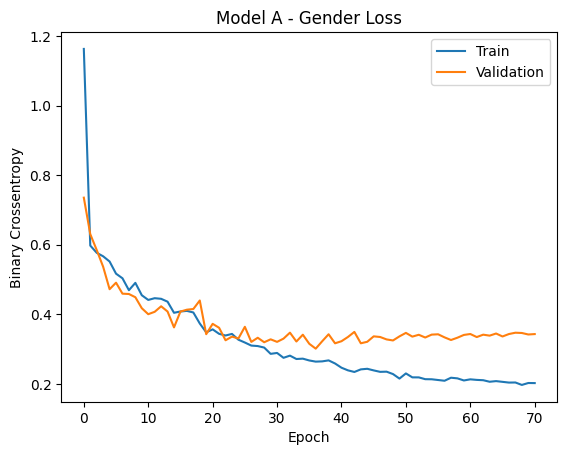

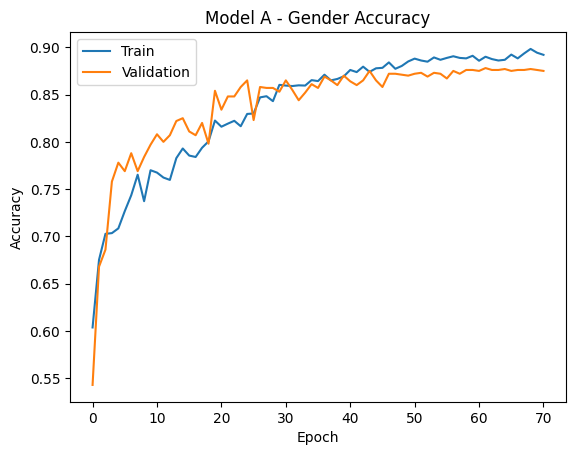

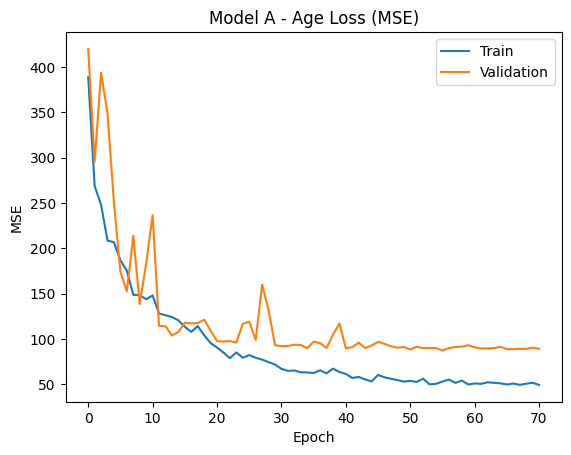

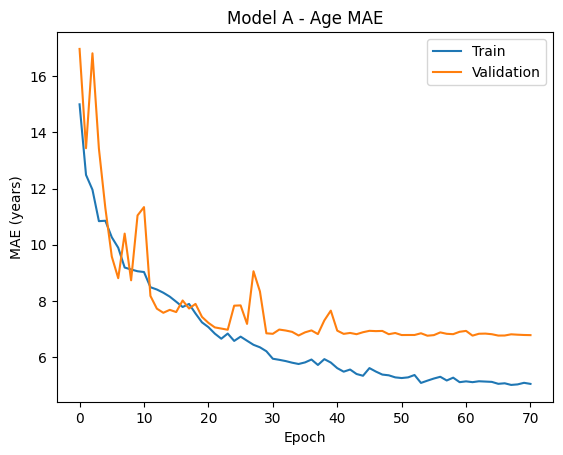

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_A.history['gender_output_loss'], label='Train')
plt.plot(history_A.history['val_gender_output_loss'], label='Validation')
plt.title('Model A - Gender Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history_A.history['gender_output_accuracy'], label='Train')
plt.plot(history_A.history['val_gender_output_accuracy'], label='Validation')
plt.title('Model A - Gender Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history_A.history['age_output_loss'], label='Train')
plt.plot(history_A.history['val_age_output_loss'], label='Validation')
plt.title('Model A - Age Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

plt.figure()
plt.plot(history_A.history['age_output_mae'], label='Train')
plt.plot(history_A.history['val_age_output_mae'], label='Validation')
plt.title('Model A - Age MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (years)')
plt.legend()
plt.show()

In [11]:
np.save('/content/drive/MyDrive/ComSci/CNN_CourseWork/history_A.npy', history_A.history)

## STEP2B: Build a CNN network based on a pre-trained model
Choose an existing CNN architecture pre-trained on ImageNet and fine-tune it on this dataset.

As with Model A, **do not resize the input image size**.
Ensure that the output layer for **the gender branch has only 1 unit**.

When constructing your model, please use only standard built-in Keras layers and functions. **Do not use Lambda layers or any custom objects (including custom layers, losses, metrics, or activation functions).** Otherwise, your model may not be correctly loaded during the testing stage.

At the end of the cell, use `modelB.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.


In [12]:
import keras

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
inputs = keras.layers.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = keras.layers.Rescaling(255.0)(x)
x = base_model(x, training=True)
x = keras.layers.GlobalAveragePooling2D()(x)

gender = keras.layers.Dense(128, activation='relu')(x)
gender = keras.layers.Dropout(0.5)(gender)
gender_output = keras.layers.Dense(1, activation='sigmoid', name='gender_output')(gender)

age = keras.layers.Dense(128, activation='relu')(x)
age = keras.layers.Dropout(0.5)(age)
age_output = keras.layers.Dense(1, activation='linear', name='age_output')(age)

modelB = keras.Model(inputs=inputs, outputs=[age_output, gender_output])

In [14]:
if modelB is not None:
  modelB.summary()
  from tensorflow.keras.utils import plot_model
  plot_model(modelB, show_shapes=True,dpi=100)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 128, 128,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 4, 4,      │  4,049,571 │ rescaling_2[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        129 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        129 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,377,765 (16.70 MB)

 Trainable params: 328,194 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## STEP3B: Compile and train your model
Compile and train your model here.
Save your model to `age_gender_B.keras` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Also, save the model with `save()` instead of `save_weights()`.**


In [15]:
modelB.compile(optimizer='adam',
              loss={'age_output': 'mse', 'gender_output': 'binary_crossentropy'},
              metrics={'age_output': 'mae', 'gender_output': 'accuracy'},
              loss_weights={'age_output': 0.1, 'gender_output': 1.0})

callbacks_B1=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

In [16]:
history_phase1 = modelB.fit(train_images,
                {'age_output': train_age, 'gender_output': train_gender},
                batch_size=32,
                epochs=30,
                validation_data=(val_images, {'age_output': val_age, 'gender_output': val_gender}),
                callbacks=callbacks_B1)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 174ms/step - age_output_loss: 395.1840 - age_output_mae: 14.7983 - gender_output_accuracy: 0.7940 - gender_output_loss: 0.4459 - loss: 39.9643 - val_age_output_loss: 225.8519 - val_age_output_mae: 11.2667 - val_gender_output_accuracy: 0.8440 - val_gender_output_loss: 0.3549 - val_loss: 23.0595
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - age_output_loss: 222.0166 - age_output_mae: 11.1927 - gender_output_accuracy: 0.8160 - gender_output_loss: 0.3953 - loss: 22.5970 - val_age_output_loss: 184.1445 - val_age_output_mae: 10.1610 - val_gender_output_accuracy: 0.8520 - val_gender_output_loss: 0.3402 - val_loss: 18.8076
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - age_output_loss: 189.1025 - age_output_mae: 10.3399 - gender_output_accuracy: 0.8372 - gender_output_loss: 0.3652 - loss: 19.2754 - val_age_output_loss: 167.9540 - val_age_output_mae: 9.6829 - val_gender_output_accuracy: 0.8560 - val_gender_output_loss: 0.3447 - val_lo

In [17]:
base_model.trainable = True

modelB.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss={'age_output': 'mse', 'gender_output': 'binary_crossentropy'},
              metrics={'age_output': 'mae', 'gender_output': 'accuracy'},
              loss_weights={'age_output': 0.1, 'gender_output': 1.0})

callbacks_B2=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
              keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)]

In [18]:
history_phase2 = modelB.fit(train_images,
                          {'age_output': train_age, 'gender_output': train_gender},
                          batch_size=32,
                          epochs=100,
                          validation_data=(val_images, {'age_output': val_age, 'gender_output': val_gender}),
                          callbacks=callbacks_B2)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - age_output_loss: 600.6209 - age_output_mae: 19.6347 - gender_output_accuracy: 0.6342 - gender_output_loss: 1.7592 - loss: 61.8213 - val_age_output_loss: 266.4683 - val_age_output_mae: 12.3260 - val_gender_output_accuracy: 0.7460 - val_gender_output_loss: 1.1504 - val_loss: 28.0646 - learning_rate: 1.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - age_output_loss: 226.3183 - age_output_mae: 11.6491 - gender_output_accuracy: 0.7107 - gender_output_loss: 1.2260 - loss: 23.8578 - val_age_output_loss: 206.1870 - val_age_output_mae: 10.6021 - val_gender_output_accuracy: 0.7510 - val_gender_output_loss: 0.9691 - val_loss: 21.5449 - learning_rate: 1.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - age_output_loss: 174.0097 - age_output_mae: 10.0750 - gender_output_accuracy: 0.7215 - gender_output_loss: 1.0067 - loss: 18.4077 - val_age_output_loss: 171.2780 - val_age_output_mae: 9.6575 - val_gender_output

In [19]:
if modelB is not None:
  modelB.save('/content/drive/MyDrive/ComSci/CNN_CourseWork/age_gender_B.keras')# You must keep the model filename unchanged for the test code to function.

## STEP4B: Draw the learning curves
Draw four learning curve figures for model B as follows.
1. The loss of the gender classification over the training and validation set
2. The accuracy of the gender classification over the training and validation set
3. The loss of the age estimation over the training and validation set
4. The MAE of the age estimation over the training and validation set

In [20]:
history_B = {}
for key in history_phase1.history:
    history_B[key] = history_phase1.history[key] + history_phase2.history[key]

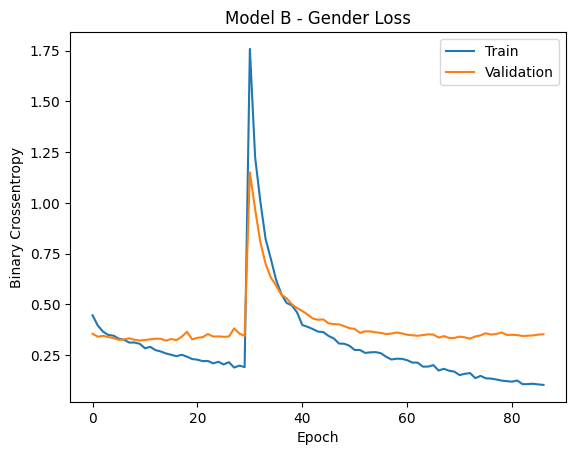

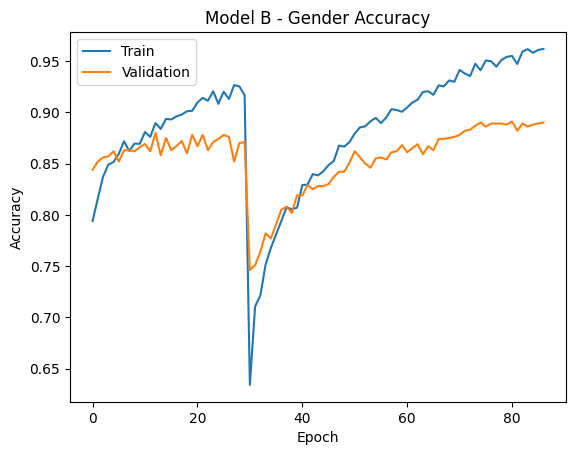

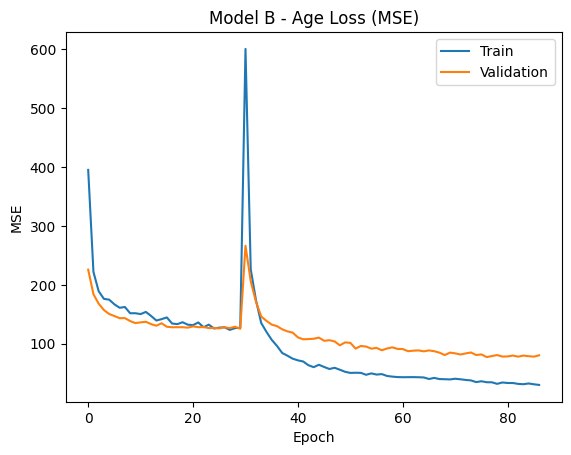

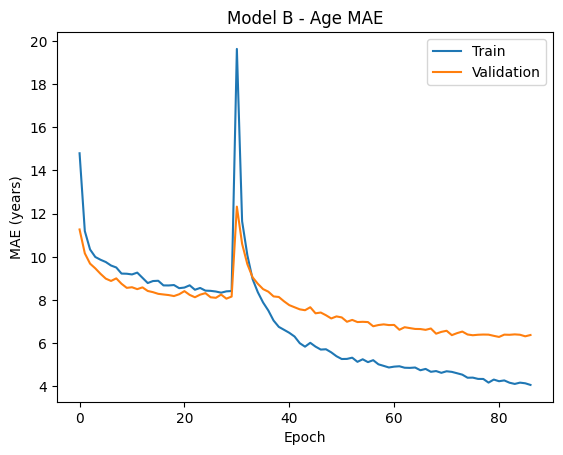

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_B['gender_output_loss'], label='Train')
plt.plot(history_B['val_gender_output_loss'], label='Validation')
plt.title('Model B - Gender Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history_B['gender_output_accuracy'], label='Train')
plt.plot(history_B['val_gender_output_accuracy'], label='Validation')
plt.title('Model B - Gender Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history_B['age_output_loss'], label='Train')
plt.plot(history_B['val_age_output_loss'], label='Validation')
plt.title('Model B - Age Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

plt.figure()
plt.plot(history_B['age_output_mae'], label='Train')
plt.plot(history_B['val_age_output_mae'], label='Validation')
plt.title('Model B - Age MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (years)')
plt.legend()
plt.show()

In [22]:
np.save('/content/drive/MyDrive/ComSci/CNN_CourseWork/history_B.npy', history_B)

## STEP5: Self-check that your models can be loaded correctly
Before running this test, **restart the runtime/kernel and run only the following cell**. This ensures that your model does not rely on any custom objects remaining in memory from the previous training stage.

Your model must be loadable using `load_model()`  without any custom objects. If the model fails to load here, it will also fail during the testing stage.


In [23]:
#
# Don't add code in this cell when submitting this file
#
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.models import load_model

# Replace this with the path to your saved model folder
your_model_folder = '/content/drive/MyDrive/ComSci/CNN_CourseWork/'
modelA = load_model(your_model_folder+'age_gender_A.keras')
modelB = load_model(your_model_folder+'age_gender_B.keras')
print("Models loaded successfully.")
#

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models loaded successfully.
